In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import mat73
import scipy.io as sio

plt.style.use('default')

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드

- 배터리 실험 원본 데이터를 python에서 읽을 수 있도록 데이터를 로드하였습니다.

- csv 파일이 아닌, MATLAB 구조체이기 때문에 안쪽에 여러 정보가 중첩되어 있는 것을 확인하였습니다.

In [10]:
DATA_DIR = Path("../data/data-30")

batch1_path = DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat"

def load_mat(path):

    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3)")
    except:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2)")

    return data

mat = load_mat(batch1_path)

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3)


## 2. batch를 list of dict로 변환

원본 batch는 Python에서 다루기 어려운 구조이므로 아래와 같은 형식으로 정리를 진행하였습니다.

```python
cell = {
  'cycle_life': ...,
  'summary': ...,
  'cycles': ...,
  ...
}
```

배터리 셀 하나, 그 셀의 수명, 그 셀의 요약 정보를 하나의 묶음으로 만들어 나중에 아래와 같이 쉽게 접근할 수 있도록 하였습니다.

```python
cell['cycle_life']
cell['summary']
```

In [11]:
batch = mat['batch']

# dict → list of dict 변환
if isinstance(batch, dict):

    keys = list(batch.keys())

    n_cells = len(batch[keys[0]])

    batch = [
        {k: batch[k][i] for k in keys}
        for i in range(n_cells)
    ]

    print("dict → list 변환 완료")

print("셀 수:", len(batch))

print("첫 셀 keys:", batch[0].keys())

dict → list 변환 완료
셀 수: 46
첫 셀 keys: dict_keys(['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary'])


## 3. feature table 만들기

코드에서 각 셀마다 아래와 같은 값들을 만들었습니다.

- cycle_life
- IR_mean
- QDischarge_mean
- Tmax_mean
- Tavg_mean
- chargetime_mean
- IR_delta
- QDischarge_delta

아는 아래와 같은 표로 만들 수 있습니다.

| 셀 | 수명 | 평균 내부저항 | 평균 방전용량 | 평균 최고온도 | 평균 충전시간 | 내부저항 변화량 | 방전용량 변화량 |
| - | -: | ------: | ------: | ------: | ------: | -------: | -------: |

머신러닝 모델은 보통 한 행을 하나의 샘플, 한 열을 하나의 feature로 한 형태를 가장 잘 다루기 때문에 이와 같이 구성하였습니다.

In [12]:
rows = []

early = 20

for cell in batch:

    summary = cell['summary']

    row = {}

    row['cycle_life'] = cell['cycle_life']

    row['IR_mean'] = np.mean(summary['IR'][:early])

    row['QDischarge_mean'] = np.mean(
        summary['QDischarge'][:early]
    )

    row['Tmax_mean'] = np.mean(
        summary['Tmax'][:early]
    )

    row['Tavg_mean'] = np.mean(
        summary['Tavg'][:early]
    )

    row['chargetime_mean'] = np.mean(
        summary['chargetime'][:early]
    )

    # degradation speed

    row['IR_delta'] = (
        summary['IR'][early] -
        summary['IR'][0]
    )

    row['QDischarge_delta'] = (
        summary['QDischarge'][0] -
        summary['QDischarge'][early]
    )

    rows.append(row)

df = pd.DataFrame(rows)

df.head()

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,chargetime_mean,IR_delta,QDischarge_delta
0,1190.0,0.015914,1.043606,33.713533,30.096830,12.719076,0.016579,-1.076547
1,1179.0,0.015200,1.026199,32.616614,29.970057,12.716683,0.016848,-1.081872
2,1177.0,0.015044,1.030038,32.972705,30.123564,12.708053,0.016692,-1.085535
3,1226.0,0.014668,1.029076,29.275209,28.625404,11.462626,0.016329,-1.084982
4,1227.0,0.015017,1.027011,32.652070,29.952887,11.445637,0.016691,-1.082842


## 4. Feature Table 확인 및 데이터 상태 점검

- Feature table 생성 이후, 데이터가 정상적으로 생성되었는지 확인하기 위해 결측치 여부를 확인하였습니다.

- df.describe()를 통해 각 feature의 평균, 표준편차, 최소값, 최대값 등을 확인하여 데이터 분포가 비정상적으로 치우치지는 않았는지 점검하였습니다.

- 또한 df.isna().sum()을 통해 결측값이 존재하는지 확인하였습니다. 결측값이 존재할 경우 상관관계 분석이나 모델 학습에서 오류가 발생하거나 결과가 왜곡될 수 있기 때문에 해당 단계를 진행하였습니다.

- 이 과정은 본격적인 데이터 분석 전, 데이터 품질을 점검하는 단계입니다.

## 5. Feature와 배터리 수명 간 상관관계 분석

- 각 feature가 배터리 수명(cycle_life)과 어떤 관계를 가지는지 확인하기 위해 상관계수(correlation)를 계산하였습니다.

> 1에 가까울수록 → 같이 증가하는 관계  
> -1에 가까울수록 → 반대로 움직이는 관계  
> 0에 가까울수록 → 관계가 거의 없음  

- 이를 통해 어떤 초기 feature가 배터리 수명과 관련이 있는지 탐색할 수 있습니다.

- 이 단계의 목적은 모델 학습 이전에 중요한 feature 후보를 식별하는 것입니다.

In [13]:
corr = df.corr()

corr

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,chargetime_mean,IR_delta,QDischarge_delta
cycle_life,1.000000,-0.008015,0.238117,-0.362276,-0.440165,0.203723,0.115008,-0.152787
IR_mean,-0.008015,1.000000,-0.063483,-0.021791,-0.116126,0.134517,0.890903,0.100500
QDischarge_mean,0.238117,-0.063483,1.000000,-0.183337,-0.162034,-0.302815,-0.113603,-0.900884
Tmax_mean,-0.362276,-0.021791,-0.183337,1.000000,0.941609,-0.060667,-0.156968,0.197760
Tavg_mean,-0.440165,-0.116126,-0.162034,0.941609,1.000000,-0.089917,-0.315192,0.117498
chargetime_mean,0.203723,0.134517,-0.302815,-0.060667,-0.089917,1.000000,0.053283,0.311979
IR_delta,0.115008,0.890903,-0.113603,-0.156968,-0.315192,0.053283,1.000000,0.109974
QDischarge_delta,-0.152787,0.100500,-0.900884,0.197760,0.117498,0.311979,0.109974,1.000000


## 6. 배터리 수명과 각 Feature 간 관계 확인

- 전체 correlation matrix 중에서 특히 중요한 것은 cycle_life와 각 feature 간 관계입니다.

- 이를 확인하기 위해 cycle_life와 다른 feature 간 상관관계만 따로 정렬하였습니다.

이 분석을 통해

>어떤 feature가 수명과 관련이 있는지  
>어떤 feature가 영향이 적은지

를 확인할 수 있습니다.

예를 들어 아래와 같은 해석을 할 수 있습니다.

> 온도 관련 feature가 음의 상관을 보인다면 초기 온도가 높을수록 배터리 수명이 짧아질 가능성이 있다.

이 단계는 feature selection을 위한 중요한 근거를 제공합니다.

In [14]:
target_corr = corr['cycle_life'].sort_values(
    ascending=False
)

target_corr

cycle_life          1.000000
QDischarge_mean     0.238117
chargetime_mean     0.203723
IR_delta            0.115008
IR_mean            -0.008015
QDischarge_delta   -0.152787
Tmax_mean          -0.362276
Tavg_mean          -0.440165
Name: cycle_life, dtype: float64

## 7. Feature와 cycle life 관계 시각화

- 상관계수를 숫자로 보는 것보다 직관적으로 이해하기 위해 bar plot으로 시각화하였습니다.

이를 통해

> 어떤 feature가 상대적으로 중요한지  
> 관계의 방향이 양인지 음인지

를 한눈에 확인할 수 있습니다.

- 시각화는 데이터 해석을 쉽게 하고 결과를 전달하는 데 중요한 역할을 합니다.

- 특히 모델링 이전 단계에서 어떤 feature가 유의미한지 판단하는 데 도움을 줍니다.

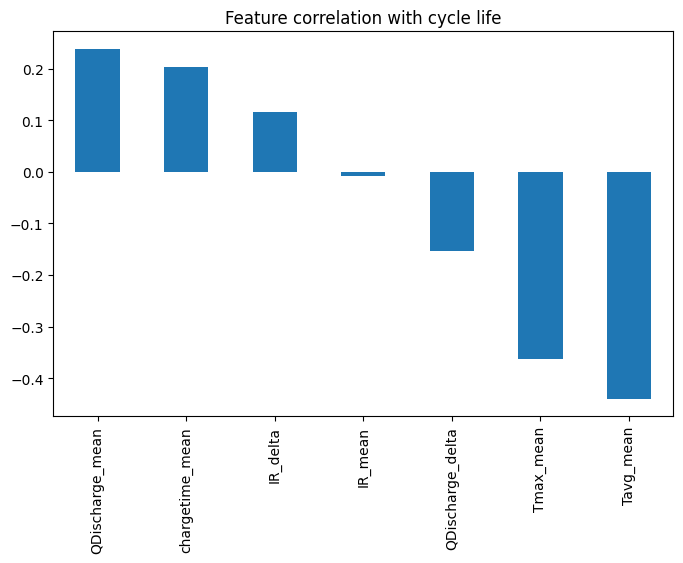

In [15]:
plt.figure(figsize=(8,5))

target_corr.drop('cycle_life').plot(
    kind='bar'
)

plt.title("Feature correlation with cycle life")

plt.show()

## 8. Feature 간 관계 분석

- Feature와 target의 관계뿐만 아니라 feature끼리 서로 얼마나 유사한 정보인지 확인하는 것도 중요합니다.

- 이를 위해 heatmap을 사용하여 feature 간 상관관계를 시각화하였습니다.

이 분석의 목적은 아래와 같습니다.

1. 서로 너무 비슷한 feature 존재 여부 확인
2. 중복 정보 제거 필요성 판단
3. 모델 안정성 확보

- 예를 들어 Tmax_mean과 Tavg_mean이 매우 높은 상관을 가진다면 두 feature는 거의 같은 정보를 담고 있을 가능성이 있습니다.

- 이러한 경우 feature selection 과정에서 하나만 사용하는 것이 더 효율적일 수 있습니다.

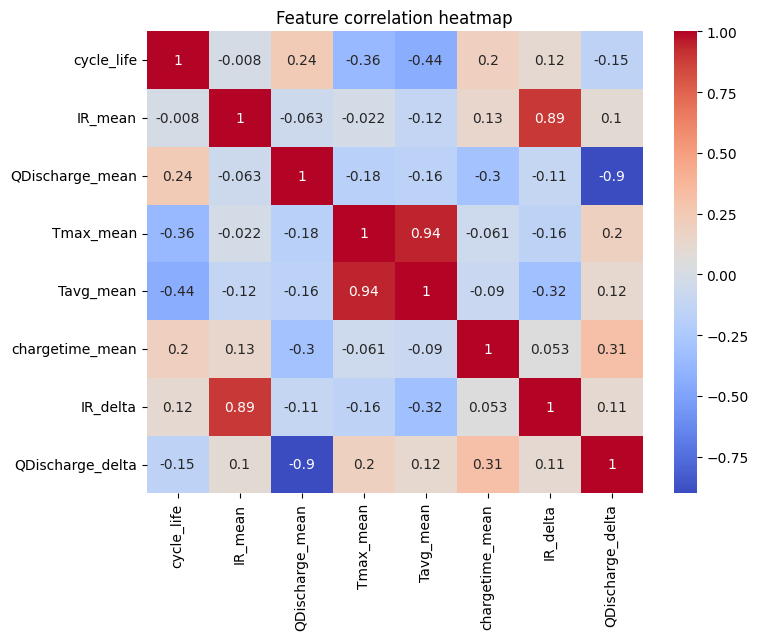

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature correlation heatmap")

plt.show()

## 9. VIF 분석 - Multicollinearity 정량적 확인

- Heatmap을 통해 feature 간 관계를 시각적으로 확인했다면, VIF(Variance Inflation Factor)를 통해 이를 정량적으로 확인할 수 있습니다.

- VIF는 한 feature가 다른 feature들로 얼마나 설명되는지를 나타내는 지표입니다.

- 일반적으로 아래와 같이 해석합니다.

> VIF < 5 → 문제 없음  
> VIF 5~10 → 주의 필요  
> VIF > 10 → multicollinearity 존재 가능

- 높은 VIF는 feature들이 서로 유사한 정보를 포함하고 있음을 의미하며, 모델 학습 시 불안정성을 유발할 수 있습니다.

- 따라서 VIF 분석은 feature selection 또는 차원 축소 필요성을 판단하는 근거가 됩니다.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['cycle_life'])

vif = pd.DataFrame()

vif["feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values, i
    )
    for i in range(len(X.columns))
]

vif

,feature,VIF
0,IR_mean,3258.892994
1,QDischarge_mean,146138.709575
2,Tmax_mean,9378.278169
3,Tavg_mean,25843.489715
4,chargetime_mean,6.653804
5,IR_delta,6083.453220
6,QDischarge_delta,191289.838791


# 10. 분석 결과 저장

- 재현 가능한 분석 환경을 만들기 위해 생성된 feature table과 correlation 결과를 CSV 파일로 저장하였숩니다.

이 작업을 통해 아래와 같은 수행이 가능합니다.

1. 팀원 간 결과 공유 가능
2. 모델링 단계에서 바로 사용 가능
3. 분석 재현성 확보

In [21]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RESULT_DIR = PROJECT_ROOT / "results"

RESULT_DIR.mkdir(exist_ok=True)

print("저장 위치:", RESULT_DIR.resolve())

df.to_csv(
    RESULT_DIR / "q5_feature_table.csv",
    index=False
)

corr.to_csv(
    RESULT_DIR / "q5_correlation.csv"
)

vif.to_csv(
    RESULT_DIR / "q5_vif.csv",
    index=False
)

저장 위치: /Users/daba/Desktop/data/data-mini/results


In [22]:
def build_q5_feature_table(cells):

    rows = []

    for cell in cells:

        row = {}

        row['cycle_life'] = cell['cycle_life']

        summary = cell['summary']

        early = 20

        row['IR_mean'] = np.mean(
            summary['IR'][:early]
        )

        rows.append(row)

    return pd.DataFrame(rows)